# FreeVIZ and SPCA comparison

In this notebook, we compare resulting vizualizations of FreeViz and SPCA for classification on four datasets.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import matplotlib.pyplot as plt
import numpy as np

import importlib
import utils
importlib.reload(utils)

from models import Freeviz
from models.spca_classification import SPCA_Classification
from utils import load_zoo_data, load_car_data, load_mushroom_data, load_glass_data, load_breast_cancer_data, scale_features, plot_projection, select_lambda_classification

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The ZOO dataset

#### Data preparation

In [3]:
E_raw, C, names, feature_names, class_names = load_zoo_data(device)
E = scale_features(E_raw)

In [4]:
# Select optimal lambda for SPCA on Zoo data
E_zoo_f64 = E.to(torch.float64)
best_lam_zoo = select_lambda_classification(SPCA_Classification, E_zoo_f64, C,
                             num_classes=len(class_names), steps=500)


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Step 0: loss = 1.8531, classifier loss = 1.8456
Step 10: loss = 1.1929, classifier loss = 1.1831
Step 20: loss = 0.9315, classifier loss = 0.9208
Step 30: loss = 0.8030, classifier loss = 0.7922
Step 40: loss = 0.6954, classifier loss = 0.6843
Step 50: loss = 0.5981, classifier loss = 0.5861
Step 60: loss = 0.5223, classifier loss = 0.5099
Step 70: loss = 0.4614, classifier loss = 0.4486
Step 80: loss = 0.4105, classifier loss = 0.3976
Step 90: loss = 0.3673, classifier loss = 0.3542
Step 100: loss = 0.3303, classifier loss = 0.3169
Step 110: loss = 0.2984, classifier loss = 0.2849
Step 120: loss = 0.2710, classifier loss = 0.2573
Step 130: loss = 0.2472, classifier loss = 0.2333
Step 140: loss = 0.2265, classifier loss = 0.2126
Step 150: loss = 0.2085, classifier loss = 0.1944
Step 160: loss = 0.1927, classifier loss = 0.1785
Step 170: loss = 0.1787, classifier loss = 0.1643
Step 180: loss = 0.1661, classifier loss = 0.1518
Step 190: loss = 0.1547, classifier loss = 0.1403
Step 200: l

#### Train FreeVIZ

In [5]:
freeviz = Freeviz(E.shape[1]).to(device)
freeviz.train(E, C)

P = freeviz(E)
A = freeviz.A
P_np = P.detach().cpu().numpy()
C_np = C.detach().cpu().numpy()
A_np = A.detach().cpu().numpy()

step: 1 loss: 18686.888671875
step: 2 loss: 18908.2890625
step: 3 loss: 20747.513671875
step: 4 loss: 19672.515625
step: 5 loss: 12327.8173828125
step: 6 loss: 11816.6328125
step: 7 loss: 11520.2734375
step: 8 loss: 11745.88671875
step: 9 loss: 12014.47265625
step: 10 loss: 12151.3095703125
step: 11 loss: 12283.1416015625


#### Train SPCA Classification

In [6]:
model = SPCA_Classification(input_dim=E.shape[1], latent_dim=2, num_classes=len(class_names), lr=0.05).to(device)
E_centered = E - E.mean(dim=0)
lam = best_lam_zoo
steps = 1000
model.train(E_centered, C, lam=lam, steps=steps, classifier_epochs=50)

L = model.L.detach().clone()
L = L - L.mean(dim=0, keepdim=True)
loading_norms = torch.norm(L, dim=1)
L = L / loading_norms.max()

Z = E_centered @ L
z_max = torch.abs(Z).max()
Z = Z / z_max

Z_np = Z.cpu().numpy()
C_np_spca = C.cpu().numpy()
L_np = L.cpu().numpy()

Step 0: loss = 2.6971, classifier loss = 1.8436
Step 10: loss = 2.0364, classifier loss = 1.1780
Step 20: loss = 1.7699, classifier loss = 0.9082
Step 30: loss = 1.6447, classifier loss = 0.7815
Step 40: loss = 1.5688, classifier loss = 0.7043
Step 50: loss = 1.5140, classifier loss = 0.6483
Step 60: loss = 1.4706, classifier loss = 0.6034
Step 70: loss = 1.4344, classifier loss = 0.5656
Step 80: loss = 1.4033, classifier loss = 0.5328
Step 90: loss = 1.3760, classifier loss = 0.5035
Step 100: loss = 1.3513, classifier loss = 0.4754
Step 110: loss = 1.3261, classifier loss = 0.4427
Step 120: loss = 1.2963, classifier loss = 0.3972
Step 130: loss = 1.2654, classifier loss = 0.3501
Step 140: loss = 1.2386, classifier loss = 0.3130
Step 150: loss = 1.2161, classifier loss = 0.2840
Step 160: loss = 1.1971, classifier loss = 0.2607
Step 170: loss = 1.1808, classifier loss = 0.2415
Step 180: loss = 1.1666, classifier loss = 0.2253
Step 190: loss = 1.1540, classifier loss = 0.2113
Step 200: l

### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


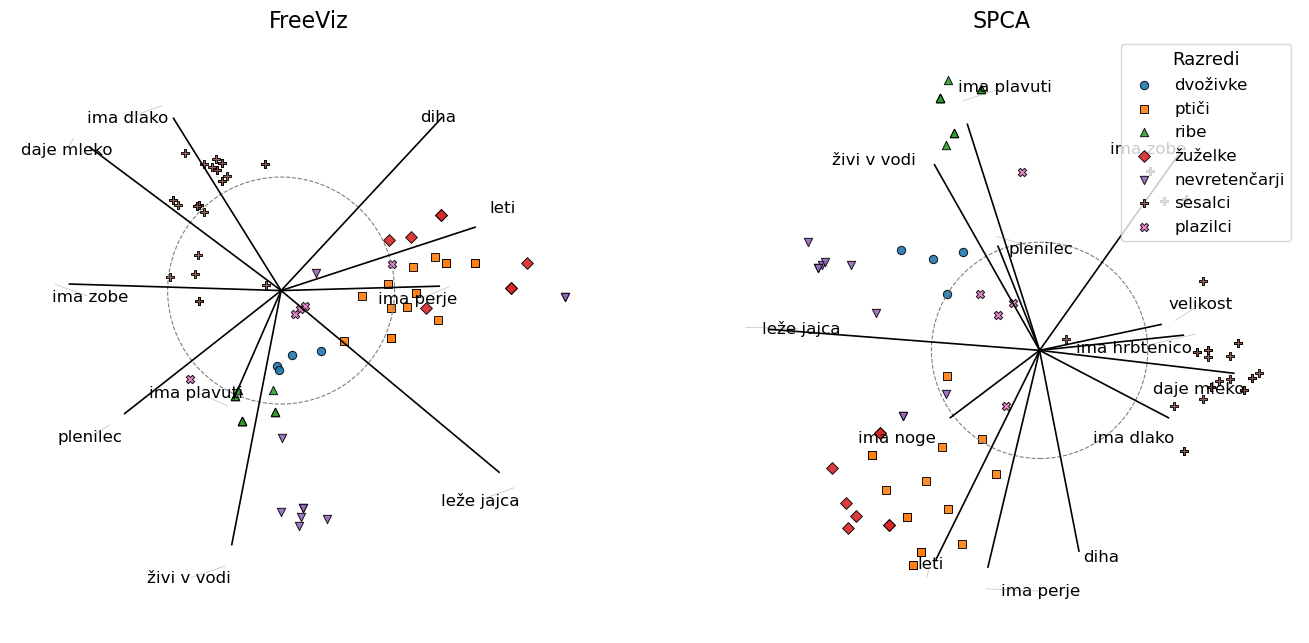

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    P_np, A_np, feature_names, C_np, class_names,
    title='FreeViz', ax=ax1, text_scale=1.08, normalize_points=True,
    show_legend=False, crop=True, label_fontsize=12, title_fontsize=16
)

plot_projection(
    Z_np, L_np, feature_names, C_np_spca, class_names,
    title='SPCA', ax=ax2, text_scale=1.1, crop=True,
    label_fontsize=12, legend_fontsize=12, legend_title_fontsize=13, title_fontsize=16
)

plt.tight_layout()
plt.savefig("../final_vizualizations/compare_freeviz_spca_zoo.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/compare_freeviz_spca_zoo.png", format="png", bbox_inches="tight")
plt.show()

# The MUSHROOM dataset

#### Data preparation

In [8]:
E_mush, C_mush, names_mush, feature_names_mush, class_names_mush = load_mushroom_data(device)
E_mush = scale_features(E_mush)

In [9]:
# Select optimal lambda for SPCA on Mushroom data
E_mush_f64 = E_mush.to(torch.float64)
best_lam_mush = select_lambda_classification(SPCA_Classification, E_mush_f64, C_mush,
                             num_classes=len(class_names_mush), steps=500)


Step 0: loss = 1.2671, classifier loss = 0.6482


Step 10: loss = 0.9793, classifier loss = 0.3521


Step 20: loss = 0.8814, classifier loss = 0.2439


Step 30: loss = 0.8333, classifier loss = 0.1874


Step 40: loss = 0.8039, classifier loss = 0.1518


...

Step 440: loss = 62051.2791, classifier loss = 0.2934


Step 450: loss = 62051.2791, classifier loss = 0.2934


Step 460: loss = 62051.2791, classifier loss = 0.2934


Step 470: loss = 62051.2791, classifier loss = 0.2934
Step 480: loss = 62051.2791, classifier loss = 0.2934


Step 490: loss = 62051.2791, classifier loss = 0.2934
lambda = 10.000000:  var_exp = 0.3289,  accuracy = 0.8750

Best lambda = 0.000100 (sum = 1.2381)


#### Train FreeVIZ

In [10]:
freeviz_mush = Freeviz(E_mush.shape[1]).to(device)
freeviz_mush.train(E_mush, C_mush)

P_mush = freeviz_mush(E_mush)
A_mush = freeviz_mush.A
P_mush_np = P_mush.detach().cpu().numpy()
C_mush_np = C_mush.detach().cpu().numpy()
A_mush_np = A_mush.detach().cpu().numpy()

step: 1 loss: 11156914.0


step: 2 loss: 2270743.25


step: 3 loss: 2286272.25


step: 4 loss: 2316779.0


step: 5 loss: 2224857.0


...

step: 7 loss: 2204252.25


step: 8 loss: 2171202.75


step: 9 loss: 2179453.0


step: 10 loss: 2232810.5


step: 11 loss: 2246996.75


#### Train SPCA Classification

In [11]:
model_mush = SPCA_Classification(input_dim=E_mush.shape[1], latent_dim=2, num_classes=len(class_names_mush), lr=0.05).to(device)
E_mush_centered = E_mush - E_mush.mean(dim=0)
model_mush.train(E_mush_centered, C_mush, lam=best_lam_mush, steps=1000, classifier_epochs=50)

L_mush = model_mush.L.detach().clone()
L_mush = L_mush - L_mush.mean(dim=0, keepdim=True)
loading_norms_mush = torch.norm(L_mush, dim=1)
L_mush = L_mush / loading_norms_mush.max()

Z_mush = E_mush_centered @ L_mush
z_max_mush = torch.abs(Z_mush).max()
Z_mush = Z_mush / z_max_mush

Z_mush_np = Z_mush.cpu().numpy()
C_mush_np_spca = C_mush.cpu().numpy()
L_mush_np = L_mush.cpu().numpy()

Step 0: loss = 1.4027, classifier loss = 0.6331


Step 10: loss = 1.1252, classifier loss = 0.3481


Step 20: loss = 1.0352, classifier loss = 0.2477


Step 30: loss = 0.9926, classifier loss = 0.1960


Step 40: loss = 0.9670, classifier loss = 0.1630


...

Step 850: loss = 0.8755, classifier loss = 0.0447
Step 860: loss = 0.8750, classifier loss = 0.0442
Step 870: loss = 0.8745, classifier loss = 0.0437


Step 880: loss = 0.8741, classifier loss = 0.0432
Step 890: loss = 0.8736, classifier loss = 0.0426
Step 900: loss = 0.8732, classifier loss = 0.0421


Step 910: loss = 0.8727, classifier loss = 0.0417
Step 920: loss = 0.8723, classifier loss = 0.0412
Step 930: loss = 0.8719, classifier loss = 0.0407


Step 940: loss = 0.8714, classifier loss = 0.0402
Step 950: loss = 0.8710, classifier loss = 0.0398
Step 960: loss = 0.8706, classifier loss = 0.0393


Step 970: loss = 0.8702, classifier loss = 0.0389
Step 980: loss = 0.8698, classifier loss = 0.0384
Step 990: loss = 0.8694, classifier loss = 0.0380


### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0


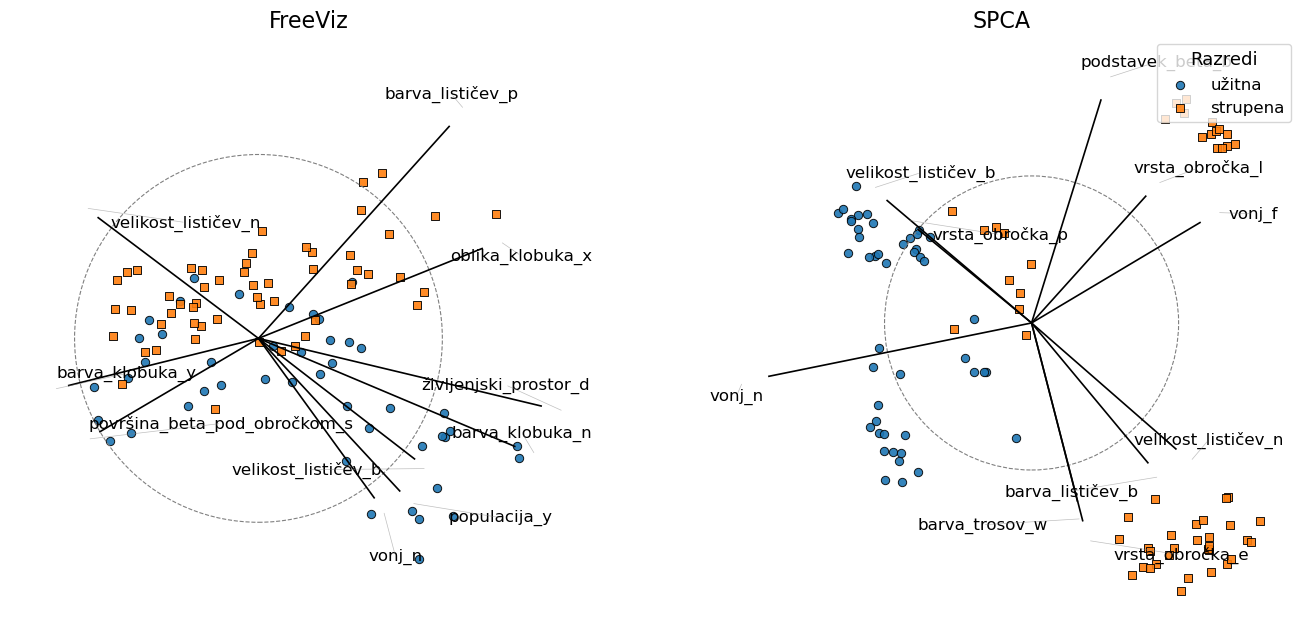

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_mush_np, vectors=A_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np, class_names=class_names_mush,
    title='FreeViz', ax=ax1, text_scale=1.08, top_n_loadings=10, normalize_points=True,
    show_legend=False, crop=True, label_fontsize=12, title_fontsize=16
)

plot_projection(
    points=Z_mush_np, vectors=L_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np_spca, class_names=class_names_mush,
    title='SPCA', ax=ax2, text_scale=1.1, top_n_loadings=10, crop=True,
    label_fontsize=12, legend_fontsize=12, legend_title_fontsize=13, title_fontsize=16
)

plt.tight_layout()
plt.savefig("../final_vizualizations/compare_freeviz_spca_mushroom.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/compare_freeviz_spca_mushroom.png", format="png", bbox_inches="tight")
plt.show()

# The BREAST CANCER dataset

#### Data preparation

In [13]:
E_bc, C_bc, names_bc, feature_names_bc, class_names_bc = load_breast_cancer_data(device)
E_bc = scale_features(E_bc)

In [14]:
# Select optimal lambda for SPCA on Breast Cancer data
E_bc_f64 = E_bc.to(torch.float64)
best_lam_bc = select_lambda_classification(SPCA_Classification, E_bc_f64, C_bc,
                             num_classes=len(class_names_bc), steps=500)


Step 0: loss = 0.6716, classifier loss = 0.6702


Step 10: loss = 0.5249, classifier loss = 0.5231


Step 20: loss = 0.4415, classifier loss = 0.4397


Step 30: loss = 0.3826, classifier loss = 0.3806


Step 40: loss = 0.3390, classifier loss = 0.3371


...

Step 400: loss = 194.4139, classifier loss = 0.2004
Step 410: loss = 194.4133, classifier loss = 0.1999
Step 420: loss = 194.4128, classifier loss = 0.1993


Step 430: loss = 194.4123, classifier loss = 0.1988
Step 440: loss = 194.4117, classifier loss = 0.1983


Step 450: loss = 194.4112, classifier loss = 0.1978
Step 460: loss = 194.4108, classifier loss = 0.1973


Step 470: loss = 194.4103, classifier loss = 0.1968
Step 480: loss = 194.4098, classifier loss = 0.1964
Step 490: loss = 194.4094, classifier loss = 0.1959


lambda = 10.000000:  var_exp = 0.8329,  accuracy = 0.9561

Best lambda = 0.053367 (sum = 1.7980)


#### Train FreeVIZ

In [15]:
freeviz_bc = Freeviz(E_bc.shape[1]).to(device)
freeviz_bc.train(E_bc, C_bc)

P_bc = freeviz_bc(E_bc)
A_bc = freeviz_bc.A
P_bc_np = P_bc.detach().cpu().numpy()
C_bc_np = C_bc.detach().cpu().numpy()
A_bc_np = A_bc.detach().cpu().numpy()

step: 1 loss: 716257.75


step: 2 loss: 1011283.625


step: 3 loss: 869568.6875


step: 4 loss: 777568.1875


step: 5 loss: 810459.25


...

step: 7 loss: 696306.125


step: 8 loss: 705954.875


step: 9 loss: 671872.9375


step: 10 loss: 696420.3125


step: 11 loss: 1880516.625


#### Train SPCA Classification

In [16]:
model_bc = SPCA_Classification(input_dim=E_bc.shape[1], latent_dim=2, num_classes=len(class_names_bc), lr=0.05).to(device)
E_bc_centered = E_bc - E_bc.mean(dim=0)
model_bc.train(E_bc_centered, C_bc, lam=best_lam_bc, steps=1000, classifier_epochs=50)

L_bc = model_bc.L.detach().clone()
L_bc = L_bc - L_bc.mean(dim=0, keepdim=True)
loading_norms_bc = torch.norm(L_bc, dim=1)
L_bc = L_bc / loading_norms_bc.max()

Z_bc = E_bc_centered @ L_bc
z_max_bc = torch.abs(Z_bc).max()
Z_bc = Z_bc / z_max_bc

Z_bc_np = Z_bc.cpu().numpy()
C_bc_np_spca = C_bc.cpu().numpy()
L_bc_np = L_bc.cpu().numpy()

Step 0: loss = 1.9587, classifier loss = 0.6628


Step 10: loss = 1.8123, classifier loss = 0.5162


Step 20: loss = 1.7302, classifier loss = 0.4340


Step 30: loss = 1.6726, classifier loss = 0.3764


Step 40: loss = 1.6302, classifier loss = 0.3339


...

Step 850: loss = 1.4683, classifier loss = 0.1716
Step 860: loss = 1.4681, classifier loss = 0.1714
Step 870: loss = 1.4680, classifier loss = 0.1712


Step 880: loss = 1.4678, classifier loss = 0.1710
Step 890: loss = 1.4677, classifier loss = 0.1709
Step 900: loss = 1.4675, classifier loss = 0.1707


Step 910: loss = 1.4674, classifier loss = 0.1706
Step 920: loss = 1.4672, classifier loss = 0.1704
Step 930: loss = 1.4671, classifier loss = 0.1703


Step 940: loss = 1.4669, classifier loss = 0.1701
Step 950: loss = 1.4668, classifier loss = 0.1700
Step 960: loss = 1.4667, classifier loss = 0.1699


Step 970: loss = 1.4666, classifier loss = 0.1698
Step 980: loss = 1.4665, classifier loss = 0.1696
Step 990: loss = 1.4663, classifier loss = 0.1695


### Side-by-side comparison

/usr/lib/python3/dist-packages/matplotlib/transforms.py:627: RuntimeWarning: invalid value encountered in scalar subtract
  deltaw = (sw * width - width) / 2.0
/usr/lib/python3/dist-packages/matplotlib/transforms.py:628: RuntimeWarning: invalid value encountered in scalar subtract
  deltah = (sh * height - height) / 2.0


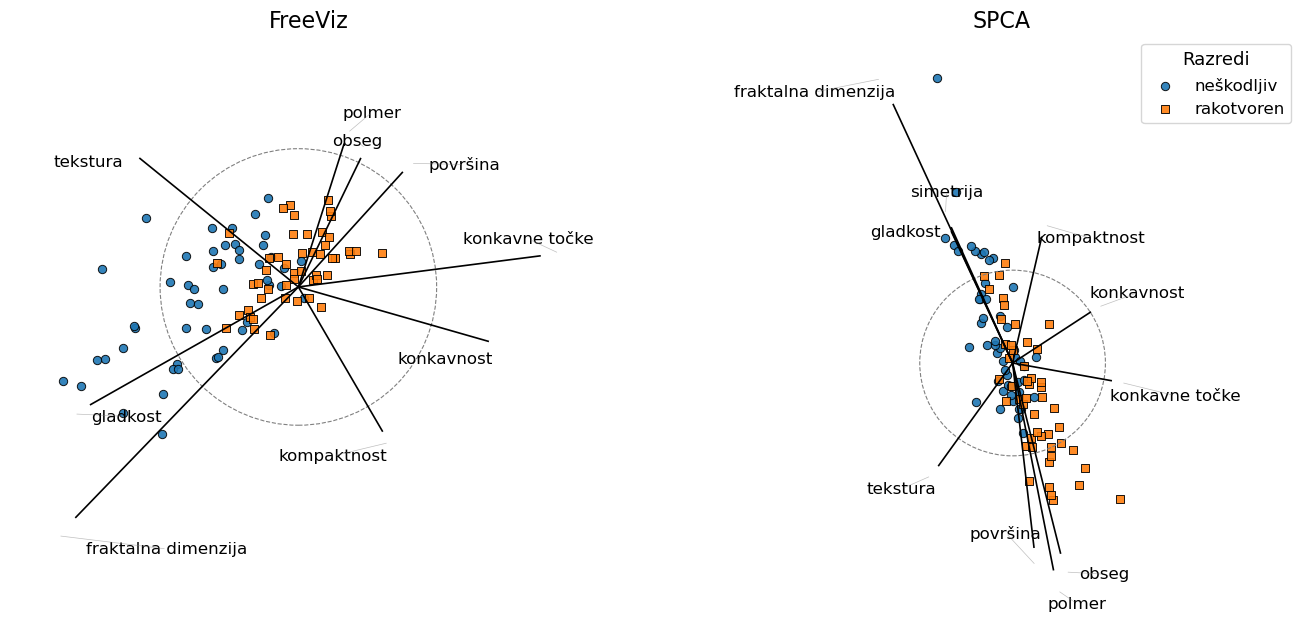

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_bc_np, vectors=A_bc_np, feature_names=feature_names_bc,
    class_codes=C_bc_np, class_names=class_names_bc,
    title='FreeViz', ax=ax1, text_scale=1.08, top_n_loadings=10, normalize_points=True,
    show_legend=False, crop=True, label_fontsize=12, title_fontsize=16
)

plot_projection(
    points=Z_bc_np, vectors=L_bc_np, feature_names=feature_names_bc,
    class_codes=C_bc_np_spca, class_names=class_names_bc,
    title='SPCA', ax=ax2, text_scale=1.1, top_n_loadings=10, crop=True,
    label_fontsize=12, legend_fontsize=12, legend_title_fontsize=13, title_fontsize=16
)

plt.tight_layout()
plt.savefig("../final_vizualizations/compare_freeviz_spca_breast_cancer.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/compare_freeviz_spca_breast_cancer.png", format="png", bbox_inches="tight")
plt.show()